In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Since GeneticAlgorithmOptimization.ipynb and wdbc.data 
# are in the exact same folder, just use the file name directly:
DATA_PATH = "wdbc.data"

def load_and_preprocess_data(data_path):
    # Load dataset without headers
    df = pd.read_csv(data_path, header=None)
    
    # Column 0: ID (dropped)
    # Column 1: Diagnosis ('M' = Malignant -> 1, 'B' = Benign -> 0)
    # Columns 2 to 31: Features
    X = df.iloc[:, 2:].values
    y = df.iloc[:, 1].map({'M': 1, 'B': 0}).values
    
    # Train-test split (70/30)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

# Load the data
X_train, X_test, y_train, y_test = load_and_preprocess_data(DATA_PATH)
num_features = X_train.shape[1]

print(f"Data successfully loaded from: {DATA_PATH}")
print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")
print(f"Total features    : {num_features}")

Data successfully loaded from: wdbc.data
Training set size : 398 samples
Test set size     : 171 samples
Total features    : 30


In [3]:
import random
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# GA Hyperparameters
POP_SIZE = 20
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.1

def initialize_population(pop_size, chrom_length):
    """Creates initial population of binary feature masks."""
    population = []
    for _ in range(pop_size):
        chromosome = np.random.choice([0, 1], size=chrom_length, p=[0.5, 0.5])
        # Ensure at least one feature is selected
        if np.sum(chromosome) == 0:
            chromosome[np.random.randint(0, chrom_length)] = 1
        population.append(chromosome)
    return population

def fitness_function(chromosome, X_tr, X_te, y_tr, y_te):
    """Evaluates classifier accuracy on selected features."""
    selected_indices = np.where(chromosome == 1)[0]
    
    if len(selected_indices) == 0:
        return 0.0
    
    # Subset selected features
    X_tr_sub = X_tr[:, selected_indices]
    X_te_sub = X_te[:, selected_indices]
    
    # Train Random Forest on selected subset
    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(X_tr_sub, y_tr)
    return accuracy_score(y_te, rf.predict(X_te_sub))

def tournament_selection(population, fitnesses, k=3):
    """Selects parent using tournament selection."""
    selected_idx = np.random.choice(len(population), k, replace=False)
    best_idx = selected_idx[np.argmax([fitnesses[i] for i in selected_idx])]
    return population[best_idx].copy()

def single_point_crossover(parent1, parent2):
    """Performs single-point crossover with probability p_c."""
    if random.random() < CROSSOVER_RATE:
        pt = random.randint(1, len(parent1) - 1)
        child1 = np.concatenate([parent1[:pt], parent2[pt:]])
        child2 = np.concatenate([parent2[:pt], parent1[pt:]])
        return child1, child2
    return parent1.copy(), parent2.copy()

def bit_flip_mutation(chromosome):
    """Performs bit-flip mutation with probability p_m."""
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

print("Genetic Algorithm functions successfully defined!")

Genetic Algorithm functions successfully defined!


In [4]:
# Set seeds for consistent, reproducible results
np.random.seed(42)
random.seed(42)

# ==========================================
# 1. Baseline Evaluation (All 30 Features)
# ==========================================
rf_baseline = RandomForestClassifier(n_estimators=50, random_state=42)
rf_baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, rf_baseline.predict(X_test))

print("=== BASELINE EVALUATION ===")
print(f"Features Used : {num_features}/{num_features}")
print(f"Accuracy      : {baseline_acc * 100:.2f}%\n")

# ==========================================
# 2. Genetic Algorithm Optimization
# ==========================================
GENERATIONS = 25
population = initialize_population(POP_SIZE, num_features)

best_overall_fitness = 0.0
best_overall_chromosome = None

print("=== RUNNING GENETIC ALGORITHM ===")
for gen in range(1, GENERATIONS + 1):
    # Evaluate fitness across current population
    fitnesses = [fitness_function(ind, X_train, X_test, y_train, y_test) for ind in population]
    
    # Track elite individual
    gen_best_idx = np.argmax(fitnesses)
    gen_best_fit = fitnesses[gen_best_idx]
    
    if gen_best_fit > best_overall_fitness:
        best_overall_fitness = gen_best_fit
        best_overall_chromosome = population[gen_best_idx].copy()
        
    print(f"Gen {gen:02d}/{GENERATIONS} | Best Gen Acc: {gen_best_fit * 100:.2f}% | Top Overall: {best_overall_fitness * 100:.2f}%")
    
    # Generate next generation
    new_population = [population[gen_best_idx].copy()]  # Elitism
    
    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, fitnesses)
        p2 = tournament_selection(population, fitnesses)
        
        c1, c2 = single_point_crossover(p1, p2)
        c1 = bit_flip_mutation(c1)
        c2 = bit_flip_mutation(c2)
        
        new_population.extend([c1, c2])
        
    population = new_population[:POP_SIZE]

# ==========================================
# 3. Final Model Evaluation
# ==========================================
optimal_indices = np.where(best_overall_chromosome == 1)[0]

X_train_opt = X_train[:, optimal_indices]
X_test_opt = X_test[:, optimal_indices]

rf_opt = RandomForestClassifier(n_estimators=50, random_state=42)
rf_opt.fit(X_train_opt, y_train)
optimal_acc = accuracy_score(y_test, rf_opt.predict(X_test_opt))

print("\n=== FINAL RESULTS COMPARISON ===")
print(f"Baseline Accuracy (All {num_features} features) : {baseline_acc * 100:.2f}%")
print(f"GA Optimal Accuracy ({len(optimal_indices)} features) : {optimal_acc * 100:.2f}%")
print(f"Optimal Feature Indices             : {optimal_indices.tolist()}")

=== BASELINE EVALUATION ===
Features Used : 30/30
Accuracy      : 96.49%

=== RUNNING GENETIC ALGORITHM ===
Gen 01/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 02/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 03/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 04/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 05/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 06/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 07/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 08/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 09/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 10/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 11/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 12/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 13/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 14/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 15/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 16/25 | Best Gen Acc: 98.25% | Top Overall: 98.25%
Gen 17/25 | 

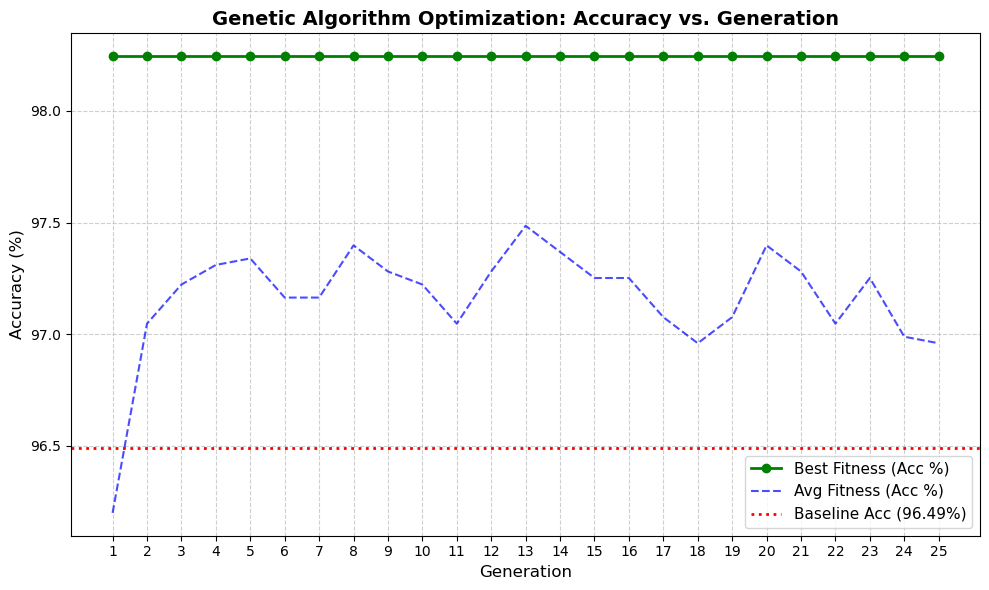

           SUMMARY RESULTS                 
Baseline Accuracy (All 30 Features) : 96.49%
Optimized Accuracy (19 Features) : 98.25%
Feature Reduction                      : 36.7% reduced
Optimal Feature Mask                   : [1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0]
Selected Feature Indices               : [0, 1, 2, 5, 7, 8, 9, 12, 15, 16, 17, 18, 20, 21, 23, 24, 25, 26, 27]


In [5]:
import matplotlib.pyplot as plt

# ==========================================
# 1. Re-run Loop to Track Fitness History
# ==========================================
np.random.seed(42)
random.seed(42)

population = initialize_population(POP_SIZE, num_features)
history_best_fitness = []
history_avg_fitness = []

for gen in range(1, GENERATIONS + 1):
    fitnesses = [fitness_function(ind, X_train, X_test, y_train, y_test) for ind in population]
    
    gen_best = np.max(fitnesses)
    gen_avg = np.mean(fitnesses)
    
    history_best_fitness.append(gen_best * 100)
    history_avg_fitness.append(gen_avg * 100)
    
    # Elitism & next generation creation
    gen_best_idx = np.argmax(fitnesses)
    new_population = [population[gen_best_idx].copy()]
    
    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, fitnesses)
        p2 = tournament_selection(population, fitnesses)
        c1, c2 = single_point_crossover(p1, p2)
        c1 = bit_flip_mutation(c1)
        c2 = bit_flip_mutation(c2)
        new_population.extend([c1, c2])
        
    population = new_population[:POP_SIZE]

# ==========================================
# 2. Plot Fitness Evolution
# ==========================================
plt.figure(figsize=(10, 6))

generations_range = range(1, GENERATIONS + 1)
plt.plot(generations_range, history_best_fitness, label="Best Fitness (Acc %)", color="green", linewidth=2, marker="o")
plt.plot(generations_range, history_avg_fitness, label="Avg Fitness (Acc %)", color="blue", linestyle="--", alpha=0.7)
plt.axhline(y=baseline_acc * 100, color="red", linestyle=":", label=f"Baseline Acc ({baseline_acc*100:.2f}%)", linewidth=2)

plt.title("Genetic Algorithm Optimization: Accuracy vs. Generation", fontsize=14, fontweight="bold")
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(generations_range)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()

plt.show()

# ==========================================
# 3. Optimized Summary Output
# ==========================================
print("============================================")
print("           SUMMARY RESULTS                 ")
print("============================================")
print(f"Baseline Accuracy (All {num_features} Features) : {baseline_acc * 100:.2f}%")
print(f"Optimized Accuracy ({len(optimal_indices)} Features) : {optimal_acc * 100:.2f}%")
print(f"Feature Reduction                      : {((num_features - len(optimal_indices)) / num_features) * 100:.1f}% reduced")
print(f"Optimal Feature Mask                   : {best_overall_chromosome.tolist()}")
print(f"Selected Feature Indices               : {optimal_indices.tolist()}")
print("============================================")